# mnist Project _ Majd

## Import Libraries

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load data

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
# shape of images = (28, 28)

In [8]:
x_test.shape[0]

10000

In [9]:
#Number of test image is 10000

In [10]:
x_train.shape[0]


60000

In [11]:
#Number of train image is 60000

In [12]:
# عرض صورة

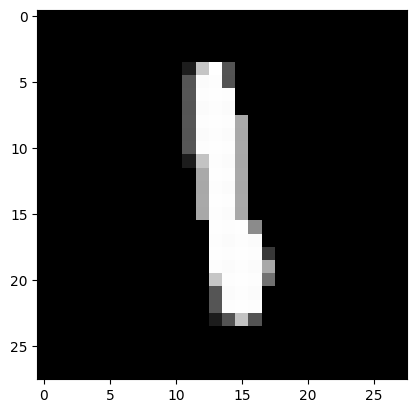

In [13]:
# عرض الصورة رقم 200
plt.imshow(x_train[200], cmap='gray')
plt.show()

##Data Preprocessing

In [14]:
x_train = x_train / 255
x_test = x_test / 255

## Build NN

In [15]:
model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)), # input Layer
        keras.layers.Dense(64, activation="relu"), # hidden Layer 1
        keras.layers.Dense(10 , activation ="softmax") # output layers
        ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
#   تجميع و تحضير المودل للتدريب

model.compile(
    optimizer="adam",
    loss=  "sparse_categorical_crossentropy", # يحسب loss
    metrics =["accuracy"] #  المقياس
)


In [17]:
# EarlyStopping
callback = tf.keras.callbacks.EarlyStopping(patience=3,monitor="val_loss",restore_best_weights=True)

In [18]:
history = model.fit(x_train, y_train, epochs=20, validation_split=0.1, callbacks=callback)
# validation_split=0.1 => x_val , y_val تقسم من بيانات التدريب تلقائيا لتكون

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9083 - loss: 0.3264 - val_accuracy: 0.9592 - val_loss: 0.1556
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9522 - loss: 0.1610 - val_accuracy: 0.9700 - val_loss: 0.1142
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9663 - loss: 0.1157 - val_accuracy: 0.9702 - val_loss: 0.1070
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9733 - loss: 0.0906 - val_accuracy: 0.9720 - val_loss: 0.0928
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9784 - loss: 0.0744 - val_accuracy: 0.9720 - val_loss: 0.0988
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0620 - val_accuracy: 0.9760 - val_loss: 0.0851
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9840 - loss: 0.0528 - val_accuracy: 0.9755 - val_loss: 0.0885
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9862 - loss: 0.0452 - 

In [19]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0832


[0.08316496759653091, 0.9750999808311462]

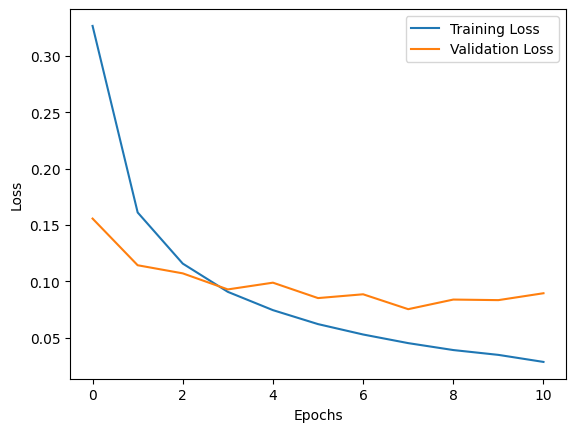

In [20]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


---

---

###Task 1 — Deep Prediction Analysis
####Select three samples from x_test

In [21]:
sample_1 = x_test[30]

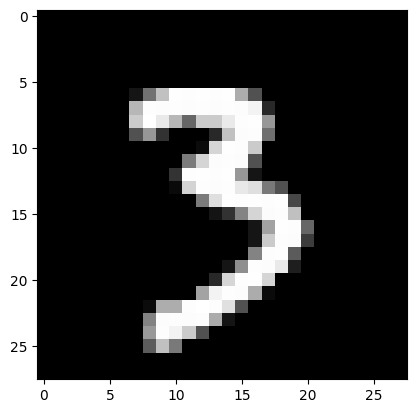

In [22]:
plt.imshow(x_test[30],cmap="gray") # عرض الصورة

In [23]:
 # القيمة الصح
print("True Label : ",y_test[30])

True Label :  3


In [24]:
prediction = model.predict(sample_1.reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [25]:
 # التوقع
print("predicton : ",np.argmax(prediction) )

predicton :  3


True Label :  4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
predicton :  4


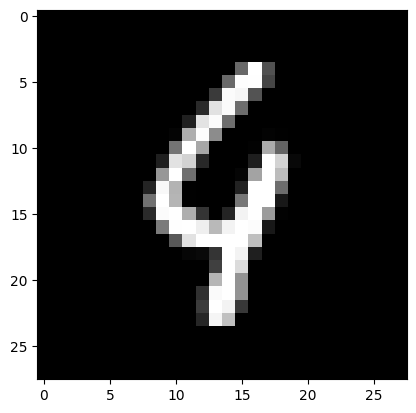

In [26]:
sample_2 = x_test[115]
plt.imshow(x_test[115],cmap="gray") # عرض الصورة
# القيمة الصح
print("True Label : ",y_test[115])
prediction_2 = model.predict(sample_2.reshape(1,28,28))
# التوقع
print("predicton : ",np.argmax(prediction_2) )

True Label :  9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
predicton :  9


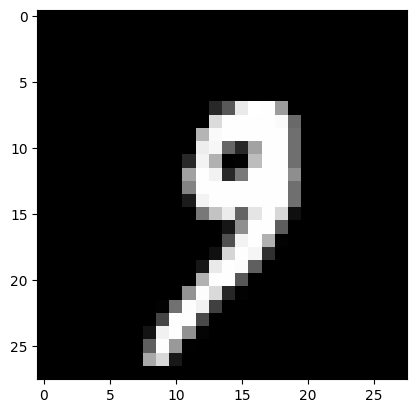

In [27]:
sample_3 = x_test[1000]
plt.imshow(x_test[1000],cmap="gray") # عرض الصورة
# القيمة الصح
print("True Label : ",y_test[1000])
prediction_3 = model.predict(sample_3.reshape(1,28,28))
# التوقع
print("predicton : ",np.argmax(prediction_3) )

---

---

###Task 2 — Custom Image Generalization Test

In [28]:
# سوف استخدم مكتبة open cv and numpy
# لمعالجة الصورة و ادخالها للمودل
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [29]:
# تحميل الصورة
img_path = '/content/drive/MyDrive/AI System Diploma/mnsit_project/results/prediction/five.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

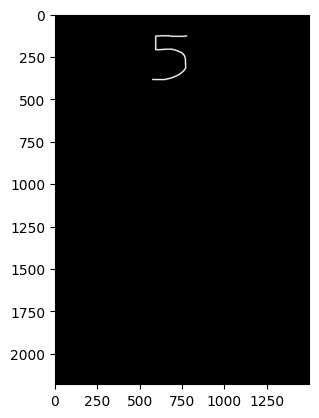

In [30]:
plt.imshow(img,cmap="gray") # عرض الصورة

In [31]:
# الرقم يقع في أعلى الصورة تماماً وحجمه صغير جداً بالنسبة للمساحة الكلية

# ايش بدي اعمل للصورة ؟؟؟

# 1. جعل الرقم في منتصف الصورة
#2. ضبط سماكة الخط
# 3. ضبط الحجم و الابعاد كما الصور التي تدرب عليها المودل
# 4. scalling

In [32]:
#توسيط الرقم
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    x, y, w, h = cv2.boundingRect(contours[0])
    digit_crop = img[y:y+h, x:x+w]
    # تسميك الخط ليتناسب مع المودل
    kernel = np.ones((5,5), np.uint8)
    digit_thick = cv2.dilate(digit_crop, kernel, iterations=2)
    pad = max(w, h) // 4
    img_processed = cv2.copyMakeBorder(digit_thick, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)
else:
    img_processed = img


In [33]:
# عمل حجم الصورة 28* 28
img_resized = cv2.resize(img_processed, (28, 28))
# scalling
custom_sample = img_resized.astype('float32') / 255.0


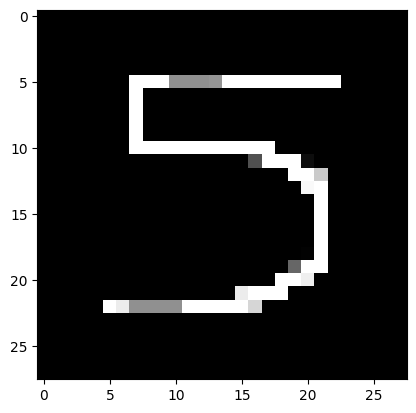

In [34]:
plt.imshow(img_resized, cmap='gray')


In [35]:
prediction = model.predict(custom_sample.reshape(1, 28, 28))
pred_label = np.argmax(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [36]:
print(f"Predicted Label: {pred_label}")


Predicted Label: 3


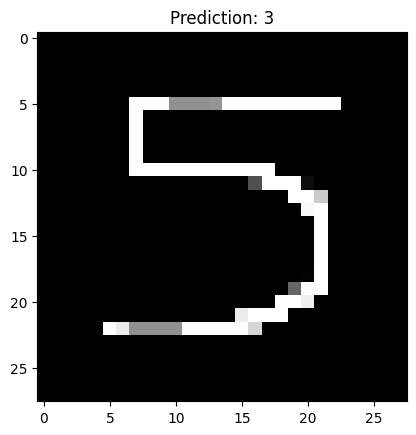

In [37]:

# عرض النتيجة
plt.imshow(img_resized, cmap='gray')
plt.title(f"Prediction: {pred_label}")
plt.show()

---


---

###Task 3 — Epoch-Based Learning Curve Exploration

5 - epoch

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8990 - loss: 0.3625 - val_accuracy: 0.9560 - val_loss: 0.1667
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9500 - loss: 0.1733 - val_accuracy: 0.9680 - val_loss: 0.1237
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9621 - loss: 0.1284 - val_accuracy: 0.9702 - val_loss: 0.1051
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9701 - loss: 0.1023 - val_accuracy: 0.9755 - val_loss: 0.0923
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9751 - loss: 0.0858 - val_accuracy: 0.9757 - val_loss: 0.0883


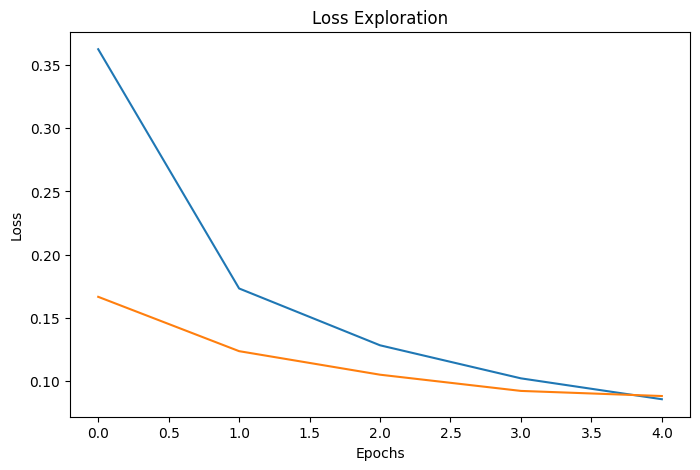

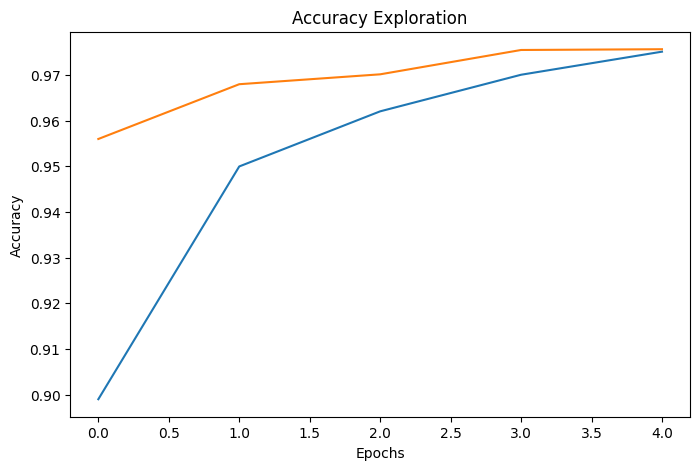

In [38]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# تدريب المودل وحفظ النتائج في history
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

#  رسم منحنى الخسارة (Loss vs Val Loss)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (loss)')
plt.plot(history.history['val_loss'], label='Validation Loss (val_loss)')
plt.title('Loss Exploration')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

#  رسم منحنى الدقة (Accuracy vs Val Accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy (accuracy)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (val_accuracy)')
plt.title('Accuracy Exploration')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

10 - epoch

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9784 - loss: 0.0735 - val_accuracy: 0.9738 - val_loss: 0.0905
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9813 - loss: 0.0635 - val_accuracy: 0.9753 - val_loss: 0.0821
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9837 - loss: 0.0555 - val_accuracy: 0.9753 - val_loss: 0.0825
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9859 - loss: 0.0487 - val_accuracy: 0.9788 - val_loss: 0.0791
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9868 - loss: 0.0432 - val_accuracy: 0.9765 - val_loss: 0.0835
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9891 - loss: 0.0382 - val_accuracy: 0.9758 - val_loss: 0.0884
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0343 - val_accuracy: 0.9775 - val_loss: 0.0822
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0300 - val_accuracy: 0.

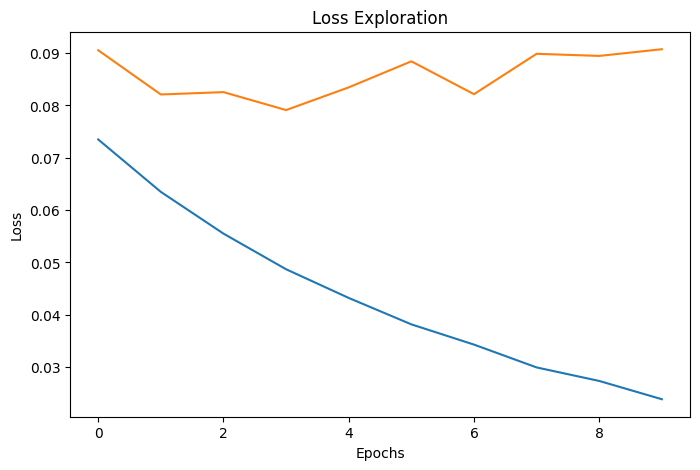

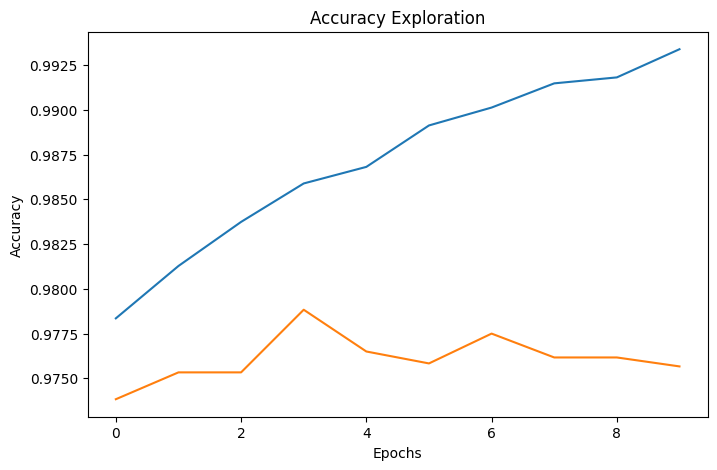

In [39]:
# تدريب المودل وحفظ النتائج في history
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

#  رسم منحنى الخسارة (Loss vs Val Loss)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (loss)')
plt.plot(history.history['val_loss'], label='Validation Loss (val_loss)')
plt.title('Loss Exploration')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

#  رسم منحنى الدقة (Accuracy vs Val Accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy (accuracy)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (val_accuracy)')
plt.title('Accuracy Exploration')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

20 - epoch

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9944 - loss: 0.0214 - val_accuracy: 0.9758 - val_loss: 0.0910
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9947 - loss: 0.0193 - val_accuracy: 0.9767 - val_loss: 0.0920
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9954 - loss: 0.0171 - val_accuracy: 0.9775 - val_loss: 0.0930
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9957 - loss: 0.0156 - val_accuracy: 0.9768 - val_loss: 0.0956
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9961 - loss: 0.0139 - val_accuracy: 0.9780 - val_loss: 0.0952
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9970 - loss: 0.0120 - val_accuracy: 0.9790 - val_loss: 0.0983
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9783 - val_loss: 0.1021
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9978 - loss: 0.0100 - val_accuracy: 0.

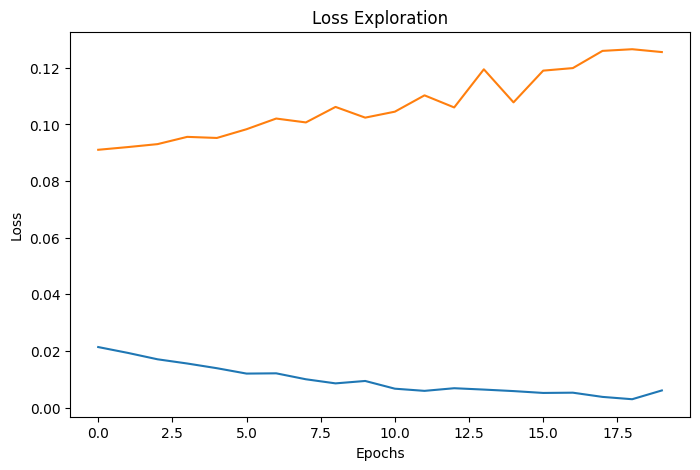

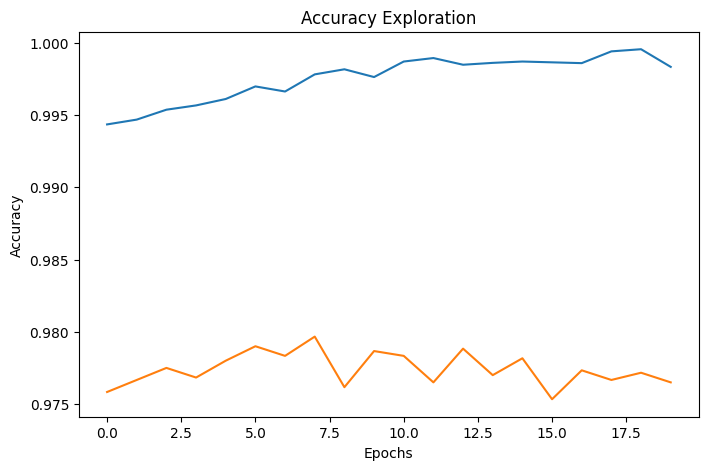

In [40]:

# تدريب المودل وحفظ النتائج في history
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

#  رسم منحنى الخسارة (Loss vs Val Loss)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (loss)')
plt.plot(history.history['val_loss'], label='Validation Loss (val_loss)')
plt.title('Loss Exploration')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

#  رسم منحنى الدقة (Accuracy vs Val Accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy (accuracy)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (val_accuracy)')
plt.title('Accuracy Exploration')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

---

---

###Task 4 — EarlyStopping Behavior Analysis

In [41]:
# إعادة بناء الموديل لضمان بداية نظيفة

model_p3 = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

model_p3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# تعريف الـ Callback
callback_p3 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# تدريب الموديل
history_p3 = model_p3.fit(x_train, y_train, epochs=50, validation_split=0.1, callbacks=[callback_p3], verbose=1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9121 - loss: 0.3133 - val_accuracy: 0.9563 - val_loss: 0.1575
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9550 - loss: 0.1517 - val_accuracy: 0.9643 - val_loss: 0.1302
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1113 - val_accuracy: 0.9695 - val_loss: 0.1038
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9728 - loss: 0.0885 - val_accuracy: 0.9740 - val_loss: 0.0935
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9783 - loss: 0.0727 - val_accuracy: 0.9737 - val_loss: 0.0922
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9816 - loss: 0.0605 - val_accuracy: 0.9697 - val_loss: 0.1004
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9838 - loss: 0.0520 - val_accuracy: 0.9732 - val_loss: 0.0929
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9863 - loss: 0.0449 - 

In [42]:
#patiens = 3 ألاحظ انه توقف عن الايبوك 10 بسبب ان الخسارة زادت 3 مرات و هذا حسب ما وضعت

In [43]:
# تجربة EarlyStopping بـ patience=5model_p5 = build_model()

# إعادة بناء الموديل لضمان بداية نظيفة

model_p5 = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

model_p5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# تعريف الـ Callback
callback_p5 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# تدريب الموديل
history_p5 = model_p5.fit(x_train, y_train, epochs=50, validation_split=0.1, callbacks=[callback_p5], verbose=1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9117 - loss: 0.3181 - val_accuracy: 0.9572 - val_loss: 0.1525
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9550 - loss: 0.1546 - val_accuracy: 0.9655 - val_loss: 0.1220
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9668 - loss: 0.1128 - val_accuracy: 0.9730 - val_loss: 0.1058
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9726 - loss: 0.0912 - val_accuracy: 0.9763 - val_loss: 0.0885
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9778 - loss: 0.0746 - val_accuracy: 0.9758 - val_loss: 0.0899
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9808 - loss: 0.0623 - val_accuracy: 0.9758 - val_loss: 0.0895
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9840 - loss: 0.0541 - val_accuracy: 0.9757 - val_loss: 0.0858
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0462 - 

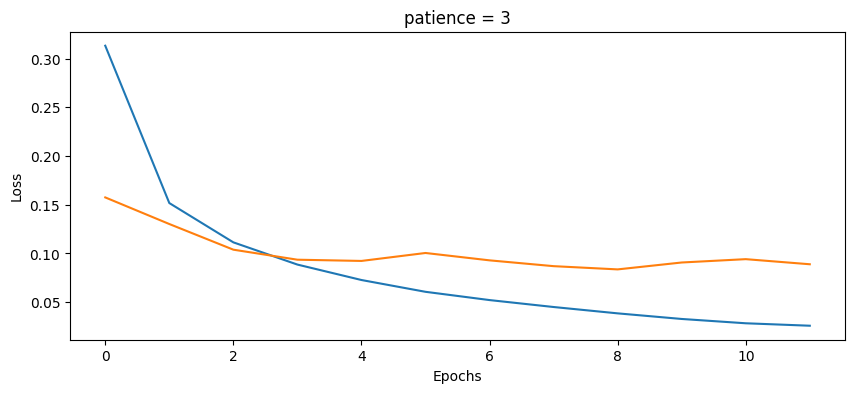

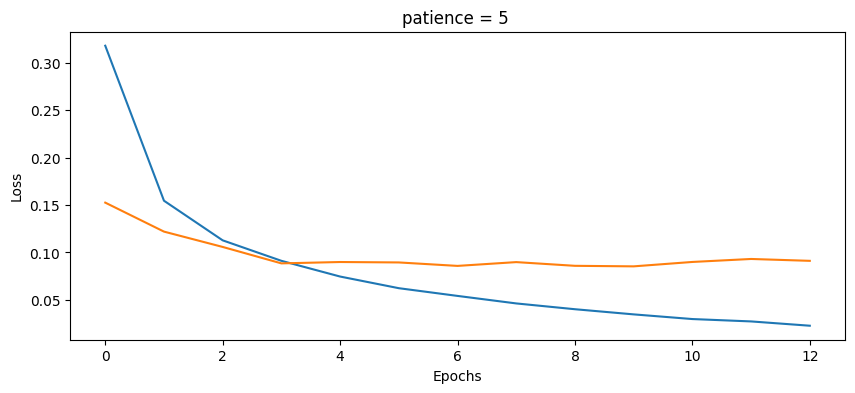

In [44]:
plt.figure(figsize=(10, 4))
plt.plot(history_p3.history['loss'], label='Train Loss')
plt.plot(history_p3.history['val_loss'], label='Val Loss')
plt.title('patience = 3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(history_p5.history['loss'], label='Train Loss')
plt.plot(history_p5.history['val_loss'], label='Val Loss')
plt.title('patience = 5 ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

---

---

###Task 7 — Optimizer Comparison Challenge

In [45]:
# كل محسن له طريقة تفكير رياضية في تحديث الأوزان
# و الهدف من التاسك مقارنة بينهم
# عشان هيك عملت لووب يمر على كل محسن من المطلوب و لعدم تكرار الكود

In [46]:
# تعريف  (Optimizers)
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD_Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'AdamW': tf.keras.optimizers.AdamW(learning_rate=0.001)
}

histories = {}

# حلقة لتدريب الموديل لكل محسن
for name, opt in optimizers.items():
    print(f"======= {name} =======")

    model_tmp = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model_tmp.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # تدريب لعدد    للمقارنة
    history = model_tmp.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
    histories[name] = history

======= SGD =======
======= SGD_Momentum =======
======= Adam =======
======= AdamW =======


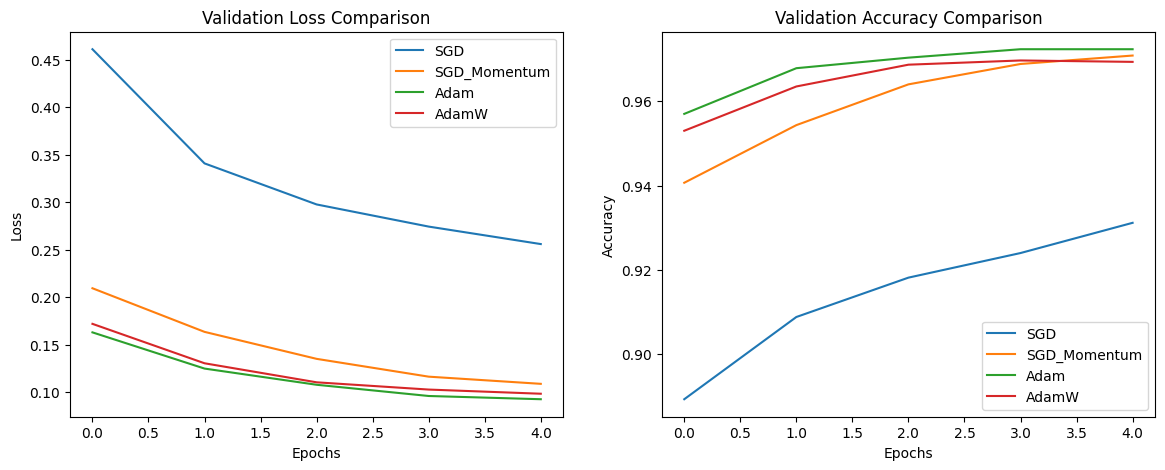

In [47]:
# رسم منحنيات المقارنة
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
for name in histories:
    plt.plot(histories[name].history['val_loss'], label=name)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
for name in histories:
    plt.plot(histories[name].history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

---

---

###**Task 8 — Batch Size & Gradient Noise Experiment**

In [48]:
# راح اعمل مثل تاسك 7
# لووب يمر على كل عدد من الايبوك المحددة و اختبارها على نفس الشبكة العصبية

==== Batch Size: 8 ====
Epoch 1/5
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9244 - loss: 0.2573 - val_accuracy: 0.9612 - val_loss: 0.1364
Epoch 2/5
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9625 - loss: 0.1221 - val_accuracy: 0.9683 - val_loss: 0.1076
Epoch 3/5
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9727 - loss: 0.0897 - val_accuracy: 0.9750 - val_loss: 0.0912
Epoch 4/5
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9774 - loss: 0.0697 - val_accuracy: 0.9762 - val_loss: 0.0862
Epoch 5/5
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9826 - loss: 0.0553 - val_accuracy: 0.9777 - val_loss: 0.0865
==== Batch Size: 32 ====
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9091 - loss: 0.3218 - val_accuracy: 0.9578 - val_loss: 0.1502
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9546 - loss: 0.1564 - val_accuracy: 0.9670 - val_loss: 0.1181
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s

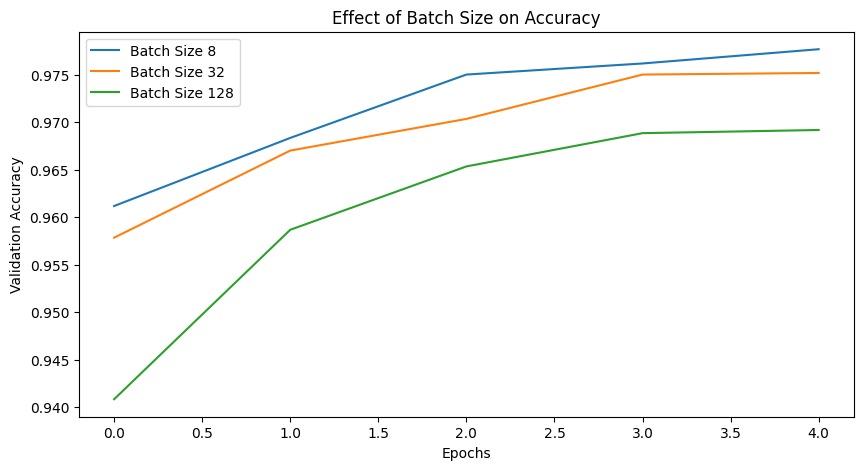

In [49]:
batch_sizes = [8, 32, 128]
batch_histories = {}

for size in batch_sizes:
    print(f"==== Batch Size: {size} ====")

    model_batch = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model_batch.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model_batch.fit(x_train, y_train, epochs=5, batch_size=size, validation_split=0.1, verbose=1)
    batch_histories[size] = history

# رسم النتائج
plt.figure(figsize=(10, 5))
for size in batch_sizes:
    plt.plot(batch_histories[size].history['val_accuracy'], label=f'Batch Size {size}')

plt.title('Effect of Batch Size on Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

---

---

###Task 9 — Activation Function Swap (ReLU vs Tanh vs GELU)


In [ ]:
## عملت لووب يمر على كل دالة تنشيط و يختبر نفس الشبكة العصبية عليهم

===== Activation: relu =====
===== Activation: tanh =====
===== Activation: softsign =====
===== Activation: gelu =====


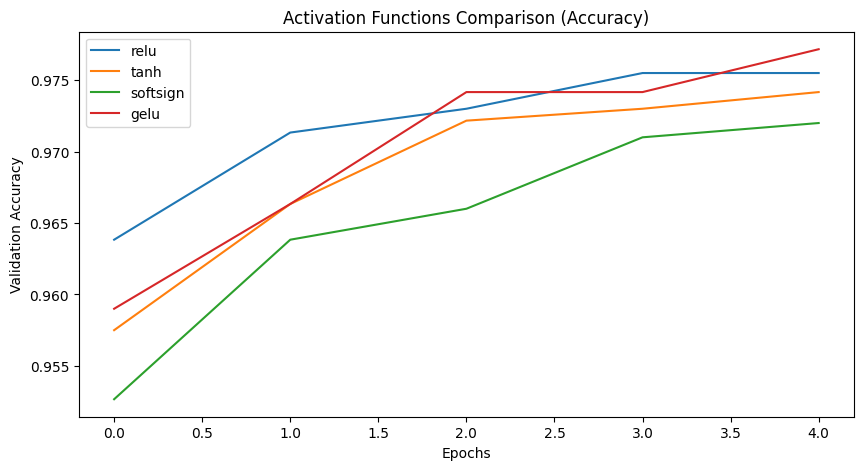

In [54]:
activations = ['relu', 'tanh', 'softsign', 'gelu']
act_histories = {}

for act in activations:
    print(f"===== Activation: {act} =====")

    model_act = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation=act),
        keras.layers.Dense(10, activation='softmax')
    ])

    model_act.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    #  Fit
    history = model_act.fit(x_train, y_train, epochs=5, batch_size=16, validation_split=0.1, verbose=0)
    act_histories[act] = history

# رسم المقارنة
plt.figure(figsize=(10, 5))
for act in activations:
    plt.plot(act_histories[act].history['val_accuracy'], label=act)

plt.title('Activation Functions Comparison (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

####Done 👌💖✨